# Associação de variáveis qualitativas

por Prof. Mauro Ribeiro - UniCEUB

## Associação entre variáveis qualitativas:

- Tabelas de dupla entrada
- Gráficos de barras
- Gráficos de mosaico
- Teste qui-quadrado.

## Aplicação com visualização e exploração de dados

Considere uma amostra dos dados de 100 mil clientes de um banco no arquivo dados_banco.csv. Estão disponíveis as variáveis:

- Cliente: Identificador do cliente.
- Sexo: Feminino (F) ou Masculino (M)
- Idade: Idade do cliente, em anos completos.
- Empresa: Tipo da empresa em que trabalha: Pública, Privada ou Autônomo
- Salário: Salário declarado pelo cliente na abertura da conta, em reais.
- Saldo_cc: Saldo em conta corrente, em reais.
- Saldo_poupança: Saldo em poupança, em reais.
- Saldo_investimento: Saldo em investimentos, em reais.
- Devedor_cartao: Valor em atraso no cartão de crédito, em reais.
- Inadimplente: Se o cliente é considerado inadimplente atualmente (1) ou não (0), de acordo com critérios preestabelecidos.


Desenvolva a exploração e visualização dos dados. Verifique possíveis associações entre variáveis.

In [ ]:
import os.path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import seaborn as sns
from scipy import stats

%matplotlib inline

# Dados banco - Leitura dos dados
dados = pd.read_csv("https://raw.githubusercontent.com/cibelerusso/VED/main/Dados/dados_banco.csv")
dados

,Cliente,Sexo,Idade,Empresa,Salario,Saldo_cc,Saldo_poupança,Saldo_investimento,Devedor_cartao,Inadimplente
0,75928,M,32,Privada,5719.00,933.79,0.0,0.0,6023.68,0
1,52921,F,28,Privada,5064.00,628.37,0.0,0.0,1578.24,0
2,8387,F,24,Autônomo,4739.00,889.18,0.0,0.0,2578.70,0
3,54522,M,30,Pública,5215.00,1141.47,0.0,0.0,4348.96,0
4,45397,M,30,Autônomo,5215.56,520.70,0.0,0.0,1516.78,1
...,...,...,...,...,...,...,...,...,...,...
9995,33487,F,31,Pública,5016.00,498.96,0.0,0.0,1263.34,0
9996,71360,M,29,Pública,5329.00,1142.82,0.0,0.0,5613.71,0
9997,92455,M,34,Privada,5581.00,885.34,0.0,0.0,1199.22,0
9998,61296,F,28,Privada,5061.00,660.74,0.0,0.0,1152.97,0


In [ ]:
dados.head()

,Cliente,Sexo,Idade,Empresa,Salario,Saldo_cc,Saldo_poupança,Saldo_investimento,Devedor_cartao,Inadimplente
0,75928,M,32,Privada,5719.00,933.79,0.0,0.0,6023.68,0
1,52921,F,28,Privada,5064.00,628.37,0.0,0.0,1578.24,0
2,8387,F,24,Autônomo,4739.00,889.18,0.0,0.0,2578.70,0
3,54522,M,30,Pública,5215.00,1141.47,0.0,0.0,4348.96,0
4,45397,M,30,Autônomo,5215.56,520.70,0.0,0.0,1516.78,1


### Classificação das variáveis por tipo

- Sexo: qualitativa nominal
- Idade: quantitativa contínua
- Empresa: qualitativa nominal
- Salário: quantitativa contínua
- Saldo_cc: quantitativa contínua
- Saldo_poupança: quantitativa contínua
- Saldo_investimento: quantitativa contínua
- Devedor_cartão: quantitativa contínua
- Inadimplente: qualitativa nominal (embora numérica)

## Variáveis qualitativas
- Sexo: qualitativa nominal
- Empresa: qualitativa nominal
- Inadimplente: qualitativa nominal (embora numérica)

### Tabela de frequências (absolutas e relativas)
### Empresa

In [ ]:
# Tabela de frequências absolutas
tab = pd.crosstab(index=dados['Empresa'], columns='Frequência')
tab

col_0,Frequência
Empresa,
Autônomo,1447
Privada,6103
Pública,2450


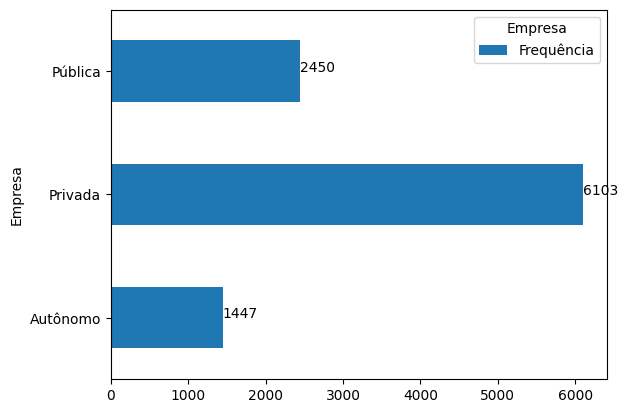

In [ ]:
tab.plot.barh()
y = tab["Frequência"]
plt.legend(title='Empresa')
for index, value in enumerate(y):
	plt.text(value, index,
			str(value))
plt.show()

In [ ]:
# Tabela de frequências Relativa
tab = pd.crosstab(index=dados['Empresa'], columns='Frequência')
tab_rel = tab/tab.sum()
tab_rel= pd.DataFrame(100*tab/tab.sum())
tab_rel.rename(columns={"Frequência": "Frequência Relativa"}, inplace=True)
tab_rel

col_0,Frequência Relativa
Empresa,
Autônomo,14.47
Privada,61.03
Pública,24.50


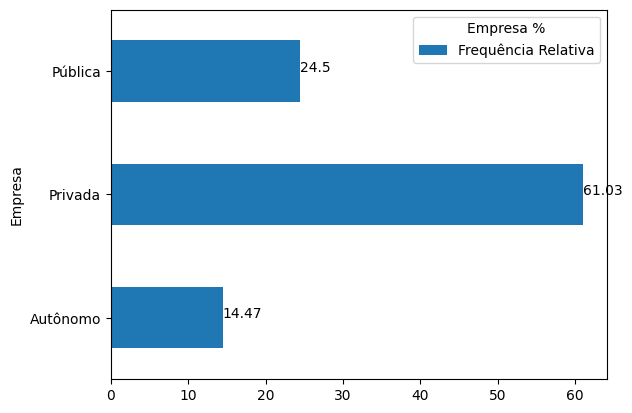

In [ ]:
tab_rel.plot.barh()
y = tab_rel["Frequência Relativa"]
plt.legend(title='Empresa %')
for index, value in enumerate(y):
	plt.text(value, index,
			str(value))
plt.show()

# Análise: Na base de dados, cerca de 62% dos clientes trabalham em empresas privadas, 24% em empresas públicas e 14% são autônomos.

### Tabela de frequências (absolutas e relativas)
### Sexo

In [ ]:
# Tabela de frequências absolutas
tab_sexo = pd.crosstab(index=dados['Sexo'], columns='Frequência')
tab_sexo

col_0,Frequência
Sexo,
F,4231
M,5769


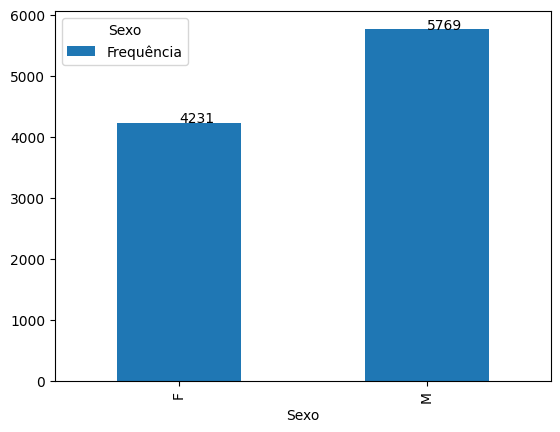

In [ ]:
tab_sexo.plot.bar()
y = tab_sexo["Frequência"]
plt.legend(title='Sexo')
for index, value in enumerate(y):
	plt.text(index, value,
			str(value))
plt.show()

In [ ]:
# Tabela de frequências relativas
tab_sexo = pd.crosstab(index=dados['Sexo'], columns='Frequência')

tab_rel_sexo= pd.DataFrame(100*tab_sexo/tab_sexo.sum())
tab_rel_sexo.rename(columns={"Frequência": "Frequência Relativa"}, inplace=True)
tab_rel_sexo

col_0,Frequência Relativa
Sexo,
F,42.31
M,57.69


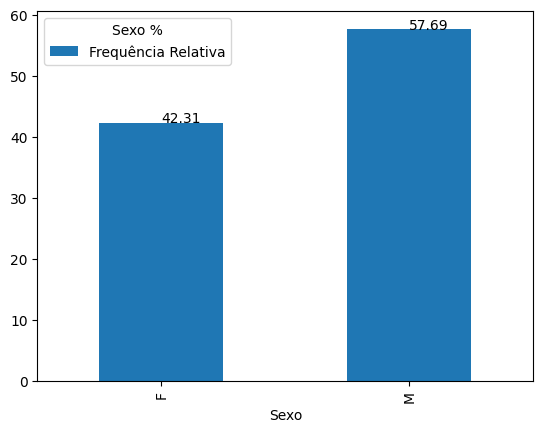

In [ ]:
tab_rel_sexo.plot.bar()
y = tab_rel_sexo["Frequência Relativa"]
plt.legend(title='Sexo %')
for index, value in enumerate(y):
	plt.text(index, value,
			str(value))
plt.show()

## Análise: Na base de dados, cerca de 58% dos clientes são do sexo masculino e 42% do sexo feminino.

# Tabela de frequências (absolutas e relativas)
# Inadimplência

In [ ]:
# Tabela de frequências absolutas
tab_inad = pd.crosstab(index=dados['Inadimplente'], columns='Frequência')
tab_inad

col_0,Frequência
Inadimplente,
0,7539
1,2461


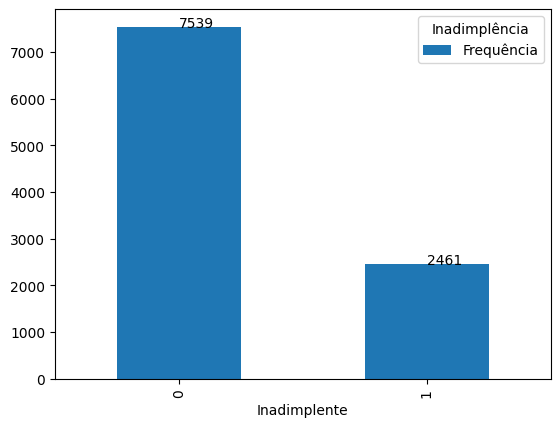

In [ ]:
tab_inad.plot.bar()
y = tab_inad["Frequência"]
plt.legend(title='Inadimplência')
for index, value in enumerate(y):
	plt.text(index, value,
			str(value))
plt.show()

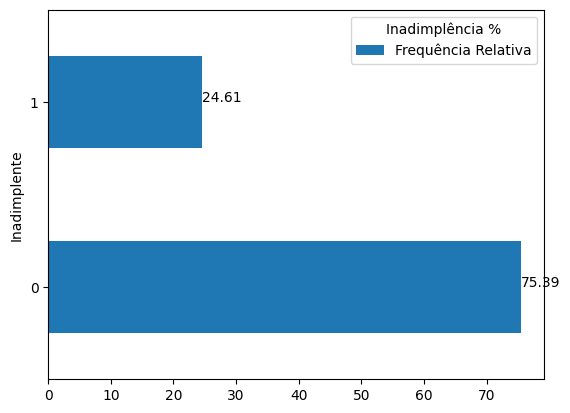

In [ ]:
# Tabela de frequências relativas
tab_inad = pd.crosstab(index=dados['Inadimplente'], columns='Frequência')

tab_rel_inad= pd.DataFrame(100*tab_inad/tab_inad.sum())
tab_rel_inad.rename(columns={"Frequência": "Frequência Relativa"}, inplace=True)

tab_rel_inad.plot.barh()
y = tab_rel_inad["Frequência Relativa"]
plt.legend(title='Inadimplência %')
for index, value in enumerate(y):
	plt.text(value, index,
			str(value))
plt.show()

# Análise Bivariada
# Associação entre duas variáveis qualitativas
Lembrando que  **58%** dos clientes são do **sexo masculino**. Questionamos se essa varíavel *sexo* *causa* algum efeito na variável *inadimplência*.
Lembramos que a **taxa de inadimplência é de 24,61%**

In [ ]:
# Tabela de frequências absolutas
tab_sexo = pd.crosstab(index=dados['Sexo'], columns='Frequência')
tab_sexo

col_0,Frequência
Sexo,
F,4231
M,5769


In [ ]:
# Tabela de dupla entrada
tabela_dupla = pd.crosstab(index=dados['Sexo'], columns=dados['Inadimplente'])
tabela_dupla

Inadimplente,0,1
Sexo,,
F,3185,1046
M,4354,1415


In [ ]:
#Valores esperados
mulher_inad = 4231*0.2461
mulher      = 4231*0.7539

homens_inad = 5769*0.2461
homens      = 5769*0.7539

d = {'Bom Cliente': [mulher, homens], 'Inadimplente': [mulher_inad, homens_inad]}
df = pd.DataFrame(data=d, index=["F", "M"])
df

,Bom Cliente,Inadimplente
F,3189.7509,1041.2491
M,4349.2491,1419.7509


In [ ]:
((3185-3189.7509)**2)/3189.7509 + ((1046-1041.2491)**2)/1041.2491 + ((4354-4349.2491)**2)/4349.2491 + ((1415-1419.7509)**2)/1419.7509


0.04984055354692471

In [ ]:
from scipy.stats import chi2_contingency
print(chi2_contingency(tabela_dupla))

Chi2ContingencyResult(statistic=0.03990183384141742, pvalue=0.8416726395363975, dof=1, expected_freq=array([[3189.7509, 1041.2491],
       [4349.2491, 1419.7509]]))


In [ ]:
# script in R
# 1-pchisq(0.03990183384141742, 1, ncp = 0, lower.tail = TRUE, log.p = FALSE)

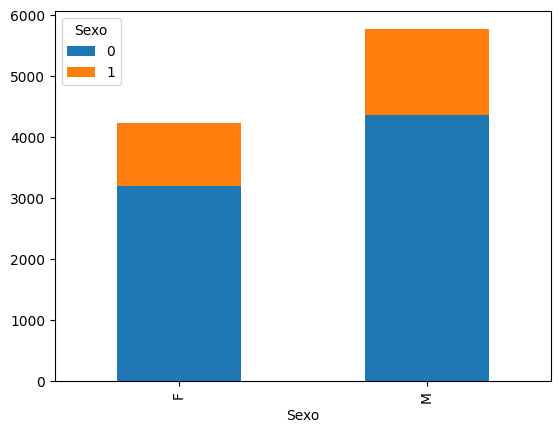

In [ ]:
tabela_dupla.plot.bar(stacked=True)
plt.legend(title='Sexo')
plt.show()

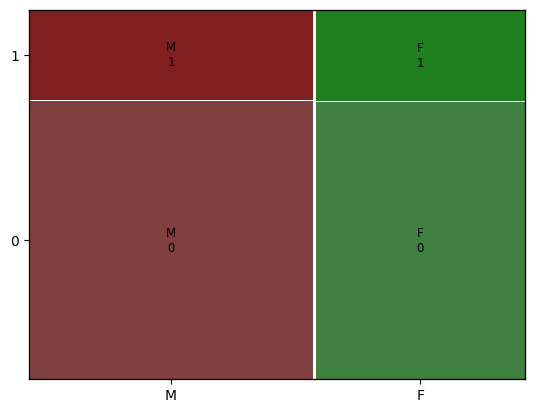

In [ ]:
from statsmodels.graphics.mosaicplot import mosaic
mosaic(dados, ['Sexo','Inadimplente']);

# Conclusão?
# A variável sexo tem alguma implicação no nível de inadimplência?

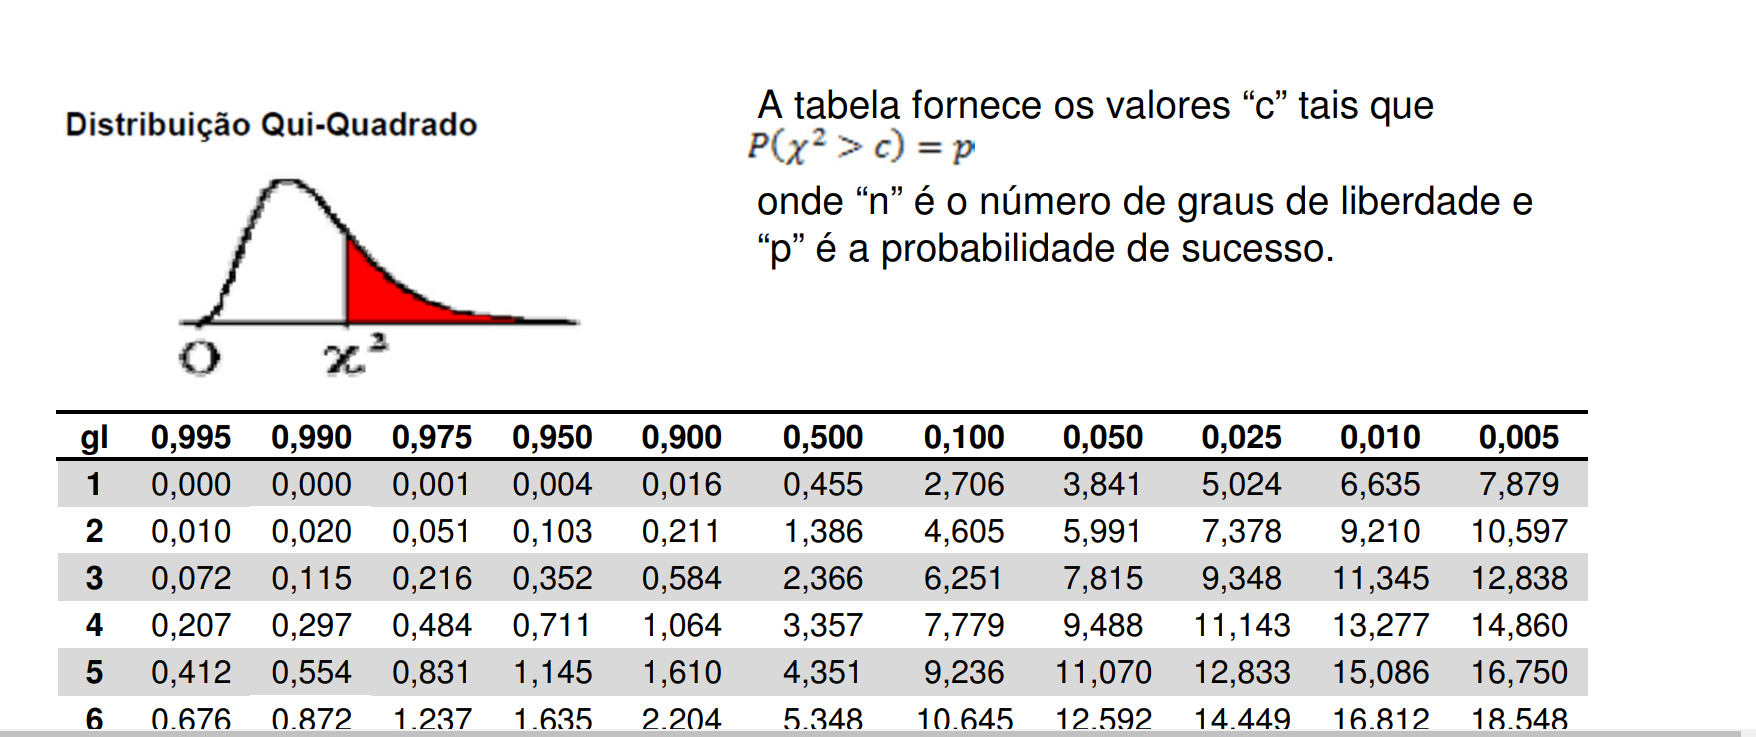

Exercício 01

In [ ]:
import os.path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import seaborn as sns
from scipy import stats

%matplotlib inline

# Dados banco - Leitura dos dados
dados = pd.read_csv("https://raw.githubusercontent.com/cibelerusso/VED/main/Dados/dados_banco.csv")
dados

,Cliente,Sexo,Idade,Empresa,Salario,Saldo_cc,Saldo_poupança,Saldo_investimento,Devedor_cartao,Inadimplente
0,75928,M,32,Privada,5719.00,933.79,0.0,0.0,6023.68,0
1,52921,F,28,Privada,5064.00,628.37,0.0,0.0,1578.24,0
2,8387,F,24,Autônomo,4739.00,889.18,0.0,0.0,2578.70,0
3,54522,M,30,Pública,5215.00,1141.47,0.0,0.0,4348.96,0
4,45397,M,30,Autônomo,5215.56,520.70,0.0,0.0,1516.78,1
...,...,...,...,...,...,...,...,...,...,...
9995,33487,F,31,Pública,5016.00,498.96,0.0,0.0,1263.34,0
9996,71360,M,29,Pública,5329.00,1142.82,0.0,0.0,5613.71,0
9997,92455,M,34,Privada,5581.00,885.34,0.0,0.0,1199.22,0
9998,61296,F,28,Privada,5061.00,660.74,0.0,0.0,1152.97,0


In [ ]:
# Tabela de frequências absolutas
tab_sexo = pd.crosstab(index=dados['Empresa'], columns=dados['Inadimplente'])
tab_sexo

Inadimplente,0,1
Empresa,,
Autônomo,832,615
Privada,4579,1524
Pública,2128,322
